# Infos.json

In [41]:
import json
from PIL import Image
import numpy as np 

In [ ]:
p = "/home/zchen/Code/NeUF_new/data/simu_56/us/us0.jpg"
# p = "/home/zchen/Code/NeUF_new/data/bluephantom/sync/export/us/us0.jpg"
im = Image.open(p).convert('L')
# resize so the largest side is 150 pixels (scales up or down)
w, h = im.size
target = 150
scale = target / max(w, h)
new_w = max(1, int(round(w * scale)))
new_h = max(1, int(round(h * scale)))
im = im.resize((new_w, new_h), Image.LANCZOS)
px_shape = np.array(im).shape
px_shape

(1632, 2447)

In [43]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.dat", "r") as f:
    lines = f.readlines()

In [ ]:
import re
pattern = r'[+-]?\d+\.\d+'
matches = re.findall(pattern, lines[0])
dimensions = [float(x) for x in matches]

[0.0, 0.0, 19.544413]

In [46]:
width = lines[1].strip().split(" ")[-2]
depth = lines[1].strip().split(" ")[-1]

In [47]:
infos_dict = {}
infos_dict['infos'] = {
    "bounding_box_3D": {
        "point_min": dimensions[:3],
        "point_max": dimensions[3:6],
        "size": dimensions[6:9]
    },
    "scan_dims_mm": {
        "width": width,
        "depth": depth
    },
    "scan_dims_px": {
        "width": px_shape[1],
        "height": px_shape[0]
    },
}

In [48]:
for i in range(1, len(lines) - 1):

    lines[i + 1].strip().split(" ")
    infos_dict[f'{i}'] = {
        "x": lines[i + 1].strip().split(" ")[0],
        "y": lines[i + 1].strip().split(" ")[1],
        "z": lines[i + 1].strip().split(" ")[2],
        "w0": lines[i + 1].strip().split(" ")[3],
        "w1": lines[i + 1].strip().split(" ")[4],
        "w2": lines[i + 1].strip().split(" ")[5],
        "w3": lines[i + 1].strip().split(" ")[6],
    }

In [52]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.json", "w") as f:
    json.dump(infos_dict, f, indent=4)

# US Image

In [1]:
from PIL import Image
import numpy as np
import os


In [27]:
imgs_path = "/home/zchen/Code/NeUF_new/data/simu_56/us"
imgs_path_new = "/home/zchen/Code/NeUF_new/data/simu_56/us_resized"
os.makedirs(imgs_path_new, exist_ok=True)
imgs_p = sorted(os.listdir(imgs_path), key=lambda x: int(x.split('us')[1].split('.jpg')[0]))
for i in range(len(imgs_p)):
    im = Image.open(os.path.join(imgs_path, imgs_p[i])).convert('L')
    im.thumbnail((150, 150), Image.LANCZOS)
    im.save(os.path.join(imgs_path_new, imgs_p[i]))

In [4]:
imgs_path = "D:\\0-Code\\NeUF\\data\\simu_56\\us"
Image.open(f"{imgs_path}\\us0.jpg").convert('L').size

(150, 100)

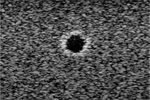

In [ ]:
import shutil

old_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us"
new_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us_0"
os.rename(old_dir, new_dir)

# Get resized US image

In [ ]:
import torch

torch.load("/home/zchen/Code/NeUF_new/logs/simu_56_neuf/checkpoints/best_model.pth")

In [2]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\bluephantom\\sync\\export\\us\\us0.jpg").convert('L')
np.array(im).shape

(173, 143)